# LPC Condor batch tutorial

This notebook runs a SidmProcessor study as unattended HTCondor batch on LPC. The pipeline is driven by the scripts in [`condor/`](../../condor/) (submitted from a terminal); the cells at the end load the merged outputs and produce sanity plots.

When to pick this path over [lpc_dask_example.ipynb](lpc_dask_example.ipynb):
- Fire-and-forget over thousands of files overnight.
- No notebook session needs to stay open during the run.
- The processor configuration is stable between submissions.

Below: two 2mu2e signal samples (`2Mu2E_500GeV_1p2GeV_1p9mm`, `2Mu2E_100GeV_0p25GeV_0p2mm`), 2 files per sample split into 2 Condor jobs of 1 file each (4 jobs total), running both `base` and `baseNoLj` selections × both `muon_base` and `electron_base` hist collections — the same configuration as [lpc_dask_example.ipynb](lpc_dask_example.ipynb). The plot grid at the end is the same 2×4 layout as the dask tutorial and the histograms are bin-for-bin identical between the two notebooks (cross-pipeline consistency check).

## Day-0 setup (do this once)

From your **laptop** terminal, with FNAL Kerberos + CMS VO + grid cert already in place (see the prerequisites section in the [top-level README](../../README.md)):

```bash
# laptop
kinit YOUR_FNAL_USERNAME@FNAL.GOV
ssh cmslpc-el9.fnal.gov
```

Then on **cmslpc**, follow the README to clone the repo, build the LCG_107 `sidm_venv`, install requirements, and register the Jupyter kernel. The Condor *submitter* (where you run `make_job_args.py` and `condor_submit`) lives in the same `sidm_venv` — no separate CMSSW setup is needed on the submitter side.

Build the venv **in place** in your checkout directory and don't move or rename it afterward — the venv records this absolute path, so a relocated checkout breaks `pip`/`jupyter` with `bad interpreter: …/sidm_venv/bin/python: No such file or directory`.

## Per-session setup (run before each submission)

```bash
# cmslpc, at the start of each working session
voms-proxy-init --valid 192:00 -voms cms
cd /uscms_data/d3/$USER/SIDM
source sidm_venv/bin/activate
```

The Condor schedd runs on a different host than the cmslpc node you SSH to and cannot read `/tmp/x509up_u<UID>` (per-node tmp). Copy the proxy to shared NFS and point `X509_USER_PROXY` at the copy:

```bash
cp /tmp/x509up_u$(id -u) /uscms_data/d3/$USER/x509_proxy.pem
chmod 600 /uscms_data/d3/$USER/x509_proxy.pem
export X509_USER_PROXY=/uscms_data/d3/$USER/x509_proxy.pem
```

The dask-from-notebook path in [lpc_dask_example.ipynb](lpc_dask_example.ipynb) does not need this copy; `lpcjobqueue` uses `use_x509userproxy = true`, which handles the spool itself.

If you run these steps from **notebook cells** rather than a terminal, the per-session `export` above sets the variable in your *shell*, not in the notebook *kernel* — and a kernel does not inherit your shell's environment. Launch Jupyter with the same `export X509_USER_PROXY=/uscms_data/d3/$USER/x509_proxy.pem` baked into the SSH command (top-README step 5) so the kernel that runs `make_job_args.py`/`condor_submit` can find the proxy.

## Files in this workflow

The `condor/` directory is the working area. You **author** these:

| File | Purpose |
|---|---|
| [`condor/signal_samples.txt`](../../condor/signal_samples.txt) / [`background_samples.txt`](../../condor/background_samples.txt) | Plain text, one sample name per line. The names match keys in `sidm/configs/ntuples/*.yaml`. |
| [`condor/submit.sub`](../../condor/submit.sub) | HTCondor submit description. Reads `arguments` and `queue` from `job_args.txt`. The `$ENV(USER)` and `$ENV(X509_USER_PROXY)` placeholders are expanded at submit time. |
| [`condor/run_job.sh`](../../condor/run_job.sh) | Shell script run by each Condor worker. Sets up CMSSW + a throwaway venv from `requirements.txt`, unpacks `sidm_code.tar.gz`, runs `run_sidm_chunk.py`, and `xrdcp`s the `.coffea` output to EOS. |
| [`condor/run_sidm_chunk.py`](../../condor/run_sidm_chunk.py) | Python entry point on the worker. Builds the fileset (with `is_data`/`skim_factor`/`year` metadata), constructs the `SidmProcessor`, and calls `processor.Runner` with `FuturesExecutor`. |
| [`condor/requirements.txt`](../../condor/requirements.txt) | Worker-side Python packages (coffea, awkward, hist, vector, uproot, …). Mirrors the versions in your `sidm_venv` so processor behaviour is consistent. |

And these are **auto-generated** by the workflow — do not commit them:

| File | Generated by | Contents |
|---|---|---|
| `condor/sidm_code.tar.gz` | `tar` (step 2 below) | Tarball of the `sidm/` source tree + `run_sidm_chunk.py`, transferred to each worker. |
| `condor/job_args.txt` | `make_job_args.py` | One line per Condor job: `SAMPLE CHUNK_ID FILELIST_PATH`. |
| `condor/filelists/SAMPLE_CHUNK.txt` | `make_job_args.py` | Per-chunk list of ROOT file URLs (one per line, xcache→EOS rewritten if you passed `--replace-xcache`). |
| `condor/logs/*.out` / `*.err` / `*.log` | HTCondor | Per-job stdout/stderr/event log. |
| `<sample>.coffea` on EOS | `run_job.sh` (chunks) / `merge_coffea_chunks_eos.py` (merged) | The processed histograms. Chunks land under `/store/user/$USER/sidm_condor/...`; merged outputs are pushed to the shared area `/store/group/lpcmetx/SIDM/coffea_outputs/$USER/<study>/`. |
| `<sample>.meta.yaml` on EOS | `merge_coffea_chunks_eos.py` (step 8) | Sidecar describing the merged file: full ROOT file list, selection definitions, hist-collection contents, schema, `unweighted_hist`, sidm git commit, coffea version, and UTC timestamp. Loaded with `sidm.tools.metadata.load_run_metadata()`. |

For the smoke test in this notebook we use parallel `smoke_*` filenames (e.g. `smoke_samples.txt`, `submit_smoke.sub`, `job_args_smoke.txt`, `filelists_smoke/`) so you can run the test without clobbering a real submission's files.

## Step 1: Author a sample list

For this end-to-end test, two samples:

```bash
# cmslpc, from /uscms_data/d3/$USER/SIDM
cat > condor/smoke_samples.txt <<'EOF'
2Mu2E_500GeV_1p2GeV_1p9mm
2Mu2E_100GeV_0p25GeV_0p2mm
EOF
```

A real signal submission lists more lines in `condor/signal_samples.txt`. See [`condor/README.md`](../../condor/README.md) §5 for examples.

## Step 2: Package the SIDM code

Rebuild whenever anything under `sidm/` or `condor/run_sidm_chunk.py` changes:

```bash
# cmslpc, from /uscms_data/d3/$USER/SIDM
tar \
    --exclude='*.root' --exclude='__pycache__' --exclude='.git' \
    --exclude='condor/logs' --exclude='condor/output' \
    --exclude='condor/filelists' --exclude='condor/filelists_smoke' \
    --exclude='condor/filelists_retry' \
    --exclude='signal_chunks' --exclude='signal_merged' \
    --exclude='background_chunks' --exclude='background_merged' \
    --exclude='sidm_venv' \
    -czf condor/sidm_code.tar.gz sidm condor/run_sidm_chunk.py
```

`condor/submit.sub` / `requirements.txt` / `run_job.sh` / `job_args.txt` / `filelists/*.txt` are transferred separately and don't need re-taring.

## Step 3: Generate job arguments and filelists

`--max-files 2 --files-per-job 1` produces 2 chunks of 1 file per sample (4 jobs total). The 2 files per sample match what the dask tutorial uses, so the `muon_pt × base × sample` cell will be bin-for-bin identical between the two notebooks.

```bash
# cmslpc, from /uscms_data/d3/$USER/SIDM
rm -rf condor/filelists_smoke && mkdir -p condor/filelists_smoke

python condor/make_job_args.py \
    --samples-file condor/smoke_samples.txt \
    --dataset llpNanoAOD_v2 \
    --location-cfg signal_2mu2e_v10.yaml \
    --max-files 2 \
    --files-per-job 1 \
    --replace-xcache \
    --outdir condor/filelists_smoke \
    --job-args condor/job_args_smoke.txt
```

Produces:
- `condor/job_args_smoke.txt` — 4 lines (2 chunks per sample × 2 samples).
- `condor/filelists_smoke/<sample>_{0,1}.txt` — 1 ROOT URL each.

For a real run, drop `--max-files` and use `--files-per-job 5` for signals or `--files-per-job 10` for backgrounds (see `condor/README.md` §6).

## Step 4: Create the EOS output directory

Each run gets its own versioned EOS directory:

```bash
xrdfs root://cmseos.fnal.gov mkdir -p /store/user/$USER/sidm_condor/SignalSmokeTest_v1
```

If you change the version (e.g. `SignalSmokeTest_v2`), update the path in the `submit_smoke.sub` `arguments` line accordingly. For real runs see `condor/README.md` §9.

## Step 5: Submit

Make a smoke-specific submit description and append the multi-X arguments (channels + hist collections) to the `arguments` line so `run_job.sh` passes them to `run_sidm_chunk.py`. `run_job.sh` reads these as positional args 5/6; if absent it falls back to `base` / `muon_base`.

```bash
# cmslpc, from /uscms_data/d3/$USER/SIDM
sed -e 's|sidm_condor/BackgroundChunks_v1|sidm_condor/SignalSmokeTest_v1 base,baseNoLj muon_base,electron_base|' \
    -e 's|job_args.txt|job_args_smoke.txt|' \
    condor/submit.sub > condor/submit_smoke.sub
```

Submit:

```bash
cd /uscms_data/d3/$USER/SIDM/condor
export X509_USER_PROXY=/uscms_data/d3/$USER/x509_proxy.pem  # NOT /tmp/... (see Per-session setup)
condor_submit submit_smoke.sub
```

Record the cluster ID and schedd from the output line `N job(s) submitted to cluster <ID>` and `Attempting to submit jobs to <SCHEDD>`.

## Step 6: Monitor

```bash
condor_q -name lpcscheddN.fnal.gov <CLUSTER_ID> -totals       # one-shot status
watch -n 10 'condor_q -name lpcscheddN.fnal.gov <CLUSTER_ID> -totals'   # live
condor_q -name lpcscheddN.fnal.gov <CLUSTER_ID> -hold         # if any held
```

When jobs are no longer in `condor_q` they are done; success is when stdout shows `return value 0`:

```bash
grep -R 'return value 0' condor/logs/*<CLUSTER_ID>*.log | wc -l
```

See `condor/README.md` §13–§16 for the full monitoring and retry workflow.

## Step 7: Reconcile and report — check the campaign before merging

Step 6 tells you the jobs *left the queue*; it does not tell you which chunks actually landed on EOS, or **why** any failed. Instead of grepping the logs by hand (and the manual retry loop in `condor/README.md` §16), [`condor/condor_campaign.py`](../../condor/condor_campaign.py) reconciles what you submitted (`job_args*.txt`) against the per-job Condor logs and the `.coffea` files on EOS, and classifies every chunk by root cause. It is **read-only** — it submits nothing, so it is safe to run any time, including while jobs are still going.

```bash
# cmslpc, from /uscms_data/d3/$USER/SIDM (sidm_venv active, or a bare python3)
python condor/condor_campaign.py reconcile \
    --job-args      condor/job_args_smoke.txt \
    --logs-dir      condor/logs \
    --eos-chunk-dir /store/user/$USER/sidm_condor/SignalSmokeTest_v1 \
    --run-id        smoke
```

This writes `condor/campaigns/smoke/report.json` + `report.md` and prints a report:

```text
CAMPAIGN TOTALS                                  chunks
  expected (from job_args) .................... 10
  DONE (on EOS, size>0) ....................... 10   (100.0%)
  failed (confirmed) ......................... 0
  - All samples complete -- ready to merge.
```

When chunks fail, each is labelled by root cause — `MISSING_ROOT_FILE` (an input confirmed gone from EOS), `EOS_TIMEOUT` (transient), `OOM`, `HELD_PROXY`, `CODE_BUG` (a processor bug a retry will not fix), and more — alongside the incomplete samples, their missing chunk indices, and a "what to do next" block. The command exits non-zero unless every chunk is DONE, so `... && merge` will not merge an incomplete campaign. See `condor/README.md` §22 for the full class list and options.

### When chunks fail

When a campaign is not all-DONE, the report names the root cause of each failed chunk. A small test campaign with three different failures -- a hung job, a processor bug, and an out-of-memory job -- produces the failure sections below (full reasons and a longer output tail are in `report.json`):

```text
FAILURE CLASSES (confirmed failures)
  STALLED               1  (stalled (guard or site policy))
  CODE_BUG              1  (deterministic python error -- NOT a retry)
  OOM                   1  (out of memory)

NON-DONE CHUNK DETAIL (root cause per chunk)
  TTToHadronic_140                 CODE_BUG        KeyError: 'LJ_pt'  [needs a human]
       last output (tail):
         |     main()
         |   File "sidm/tools/sidm_processor.py", line 210, in process
         |     lj_pt = events.LJ_pt
         | KeyError: 'LJ_pt'
  QCD_Pt600To800_22                OOM             out of memory (signal 9 / exit 137 / peak 3990 MB of 4096 MB)
  QCD_Pt800To1000_63               STALLED         stalled (no progress for ~48h before removal): SYSTEM_PERIODIC_REMOVE
       last output (tail):
         | Processing chunk 1/12
         | Processing chunk 2/12
         | Opening root://cmseos.fnal.gov//store/data/slow_huge_file.root

WHAT TO DO NEXT
  - 1 OOM chunk(s): resubmit at higher request_memory.
  - 1 CODE_BUG chunk(s): a deterministic python error -- fix the processor and rebuild sidm_code.tar.gz; a plain retry will re-fail.
  - sample(s) incomplete -- DO NOT merge them yet. Complete samples are ready to merge.
```

The `[needs a human]` tag marks failures a retry will not fix (a code bug, a manual removal). The `last output (tail)` is the end of the job's own stdout/stderr -- here the stalled job was stuck opening one slow file, and the code-bug job hit a missing `LJ_pt` field. `report.json` carries the same per-chunk detail (class, reason, offending files, last output) for programmatic use.

## Step 8: Merge chunks from EOS, with sidecar, into the shared lpcmetx area

Accumulate per-chunk `.coffea` files into one per sample. `--filelists-dir` + `--selections` + `--hist-collections` make the merge script also write a `.meta.yaml` sidecar next to each merged file. Pass the same comma-separated channels + hist collections that were used at submit time:

```bash
# cmslpc, from /uscms_data/d3/$USER/SIDM (sidm_venv active)
python sidm/scripts/merge_coffea_chunks_eos.py \
    --input-eos-dir  /store/user/$USER/sidm_condor/SignalSmokeTest_v1 \
    --output-eos-dir /store/group/lpcmetx/SIDM/coffea_outputs/$USER/smoke_v1 \
    --workdir merge_tmp_smoke \
    --filelists-dir condor/filelists_smoke \
    --selections base,baseNoLj \
    --hist-collections muon_base,electron_base \
    --schema LLPNanoAODSchema --chunksize 50000 --unweighted-hist
```

The script `xrdcp`s the chunks down, runs `processor.accumulate()`, `xrdcp`s the merged `.coffea` and the `.meta.yaml` sidecar to the shared lpcmetx area, and cleans up the local workdir.

Chunks under `/store/user/$USER/sidm_condor/...` are retained after the merge. Append `--delete-chunks-after-merge` to the command above to remove them from EOS once the merge has been verified. See `condor/README.md` §17 for backgrounds vs signals.

## Load a study back from lpcmetx (yours or a collaborator's)

Outputs live under `/store/group/lpcmetx/SIDM/coffea_outputs/<producer>/<study>/` on EOS (group-writable, world-readable). `coffea.util.load` / `load_run_metadata` open **local files** (they don't accept a `root://` URL), and LPC recommends accessing EOS over **xrootd**, *not* the `/eos/uscms` FUSE mount (the mount degrades the shared interactive node and isn't available on batch workers). So the pattern is: `xrdfs … ls` to discover the files, `xrdcp` each `.coffea` **and** its `.meta.yaml` down to a local scratch dir, then `load` the local copies.

Set `PRODUCER` to whoever produced the study — your own `$USER`, or a **collaborator's** username to read theirs. **VOMS:** reading these world-readable files works with your Kerberos ticket; only the *write/save* side needs a valid VOMS proxy (`voms-proxy-init --valid 192:00 -voms cms`).

In [1]:
import os, glob, subprocess
import matplotlib.pyplot as plt
from coffea.util import load
from sidm.tools import utilities
from sidm.tools.metadata import load_run_metadata

utilities.set_plot_style()
%matplotlib inline

In [ ]:
# coffea.util.load / load_run_metadata open LOCAL files (no root:// URLs), and LPC
# recommends xrootd over the /eos/uscms FUSE mount -- so xrdcp the study's files
# down, then load the local copies. Reads work with your Kerberos ticket.
# Set PRODUCER to a COLLABORATOR's username to read theirs (not yours).
PRODUCER = os.environ["USER"]
STUDY    = "smoke_v1"
REDIR    = "root://cmseos.fnal.gov"
EOS_DIR  = f"/store/group/lpcmetx/SIDM/coffea_outputs/{PRODUCER}/{STUDY}"
LOCAL    = f"/uscms_data/d3/{os.environ['USER']}/SIDM/imported/{PRODUCER}_{STUDY}"
os.makedirs(LOCAL, exist_ok=True)

# discover on EOS (xrootd) and copy each .coffea AND its .meta.yaml down to LOCAL
try:
    remote = subprocess.run(["xrdfs", REDIR, "ls", EOS_DIR],
                            check=True, capture_output=True, text=True).stdout.split()
except subprocess.CalledProcessError:
    raise FileNotFoundError(f"{EOS_DIR} not found on EOS -- check PRODUCER ({PRODUCER}) and STUDY ({STUDY}).")
if not any(r.endswith(".coffea") for r in remote):
    raise FileNotFoundError(f"No .coffea under {EOS_DIR} -- check PRODUCER/STUDY (a collaborator's dir may be empty).")
for r in remote:
    if r.endswith((".coffea", ".meta.yaml")):
        subprocess.run(["xrdcp", "-f", f"{REDIR}/{r}", f"{LOCAL}/{os.path.basename(r)}"], check=True)

# load from the LOCAL copies; flatten to {sample: per-sample dict}
samples_out, metas = {}, {}
for path in sorted(glob.glob(f"{LOCAL}/*.coffea")):
    obj = load(path)
    for sample, per_sample in obj.get("out", obj).items():
        samples_out[sample] = per_sample
    metas[os.path.basename(path)[:-len(".coffea")]] = load_run_metadata(path)

print("xrdcp'd", len(samples_out), "sample(s) to", LOCAL)
print("samples        :", list(samples_out.keys()))
s0 = next(iter(samples_out))
print(f"per-sample keys: {list(samples_out[s0].keys())}")
print("hists (first 8):", list(samples_out[s0]["hists"].keys())[:8])
print("channels       :", list(samples_out[s0]["cutflow"].keys()))

xrdcp'd 2 sample(s) to /uscms_data/d3/murtazas/SIDM/imported/murtazas_smoke_v1
samples        : ['2Mu2E_100GeV_0p25GeV_0p2mm', '2Mu2E_500GeV_1p2GeV_1p9mm']
per-sample keys: ['cutflow', 'hists', 'counters', 'metadata']
hists (first 8): ['muon_n', 'muon_pt', 'muon_dxy', 'muon_eta_phi', 'muon_absD0', 'muon_absD0_lowRange', 'muon_numOverlapSegments_matchedDSAMuons', 'muon_numOverlapSegments_goodMatchedDSAMuons']
channels       : ['base', 'baseNoLj']


## What's in the output `.coffea`

`coffea.util.load(path)` returns a `dict`. A processor run through coffea's `Runner` is wrapped with three top-level keys:

- **`out`** — the accumulator (the actual results): a `dict` keyed by **sample (dataset) name**, e.g. `out["2Mu2E_500GeV_1p2GeV_1p9mm"]`. A dask single-file output and a condor merged output have the *same* shape here; merging just sums the per-sample contents.
- **`processed`** — a `set` of coffea `WorkItem`s, **one per (file, entry-range) chunk that was processed**. Each carries `dataset`, `filename`, `treename`, the entry range `entrystart`/`entrystop`, `fileuuid`, and `usermeta` — the exact provenance of what went in; `len(out["processed"])` is the number of chunks.
- **`exception`** — **`0` on a clean run.** coffea stores the executor's trailing return code here, so it stays `0` when processing finished without an executor-level error (a non-zero value would flag a failure during the run).

Each `out["<sample>"]` is a `dict` with four keys:

- **`hists`** — `{hist_name: hist.Hist}`. Each `Hist` uses **Weight** storage (bins are `WeightedSum(value, variance)` — read `.value` / `.variance`, don't cast to `float`). Its **first axis is `channel`**, a `StrCategory` of the selection names, so you pick a selection by string: `hists["muon_pt"]["base", :]` returns the physics histogram for that channel, and `.sum()` gives its `WeightedSum`.
- **`cutflow`** — `{channel: SimpleCutflow}`; each cutflow's `.rows` is an ordered `{cut_name: {"raw": int, "weighted": float}}` (the `"None"` row is the pre-cut total).
- **`counters`** — `{lj_reco: {channel: {counter_name: int}}}` — event/object tallies.
- **`metadata`** — `{n_evts, scaled_sum_weights, year, is_data}` — per-sample bookkeeping.

The available channels (selections) are `list(out["<sample>"]["cutflow"].keys())`.

**Optional `debug` output:** constructing `SidmProcessor(..., debug=True)` adds a fifth per-sample key, `debug` — `out["<sample>"]["debug"][lj_reco][channel][branch].value` holds the raw, unbinned per-event arrays behind the histograms (the default branches are `passing_weights` and `gen_weights`; supply analysis-specific ones via `debug_branches`). Off by default. See [`debug_branch_demo.ipynb`](debug_branch_demo.ipynb) and the `SidmProcessor` docstring.

## The `.meta.yaml` sidecar

Every `.coffea` is written with a `<name>.meta.yaml` next to it (via `sidm.tools.metadata`). `load_run_metadata(coffea_path)` reads it — it derives `<name>.meta.yaml` from the path you pass, so the `.coffea` itself need not be opened. Keys:

| key | meaning |
|---|---|
| `created_utc` | UTC write timestamp |
| `coffea_path` | path of the `.coffea` it describes |
| `n_samples` | number of samples in the fileset |
| `selections` | `[{name, definition}]` — each requested selection and its `selections.yaml` block |
| `hist_collections` | `[{name, hists}]` — each collection and its histogram names |
| `schema` | schema used (e.g. `LLPNanoAODSchema`) |
| `chunksize` | processor chunksize |
| `unweighted_hist` | whether hists were filled unweighted |
| `sidm_commit` | SIDM `git HEAD` that produced it |
| `coffea_version` | coffea version |
| `samples` | `[{name, n_files, xsec_pb, metadata, files}]` — per sample: file count, cross section (pb; `null` if unknown), the input fileset's per-sample `metadata` dict, and the full input ROOT file list |
| `n_chunks` | **condor-merged outputs only** — number of chunks accumulated (the merge script injects it; dask sidecars don't have it) |

In [3]:
for name, m in metas.items():
    print(f"=== {name}.meta.yaml ===")
    print("  created_utc   :", m["created_utc"])
    print("  selections    :", [s["name"] for s in m["selections"]])
    print("  hist_colls    :", [(hc["name"], f"{len(hc['hists'])} hists") for hc in m["hist_collections"]])
    print("  schema        :", m["schema"], "| chunksize:", m["chunksize"], "| unweighted:", m["unweighted_hist"])
    print("  sidm_commit   :", m["sidm_commit"])
    print("  coffea_version:", m["coffea_version"])
    if "n_chunks" in m:                       # condor-merged sidecars only
        print("  n_chunks      :", m["n_chunks"])
    for s in m["samples"]:
        print(f"    {s['name']}: {s['n_files']} files, xsec_pb={s['xsec_pb']}")

=== 2Mu2E_100GeV_0p25GeV_0p2mm.meta.yaml ===
  created_utc   : 2026-05-28T16:50:08Z
  selections    : ['base', 'baseNoLj']
  hist_colls    : [('muon_base', '13 hists'), ('electron_base', '19 hists')]
  schema        : LLPNanoAODSchema | chunksize: 50000 | unweighted: True
  sidm_commit   : 547f6cecce65f24b474e48c2723aeebd06c136ad
  coffea_version: 2025.5.0rc2
  n_chunks      : 2
    2Mu2E_100GeV_0p25GeV_0p2mm: 2 files, xsec_pb=0.001
=== 2Mu2E_500GeV_1p2GeV_1p9mm.meta.yaml ===
  created_utc   : 2026-05-28T16:50:08Z
  selections    : ['base', 'baseNoLj']
  hist_colls    : [('muon_base', '13 hists'), ('electron_base', '19 hists')]
  schema        : LLPNanoAODSchema | chunksize: 50000 | unweighted: True
  sidm_commit   : 547f6cecce65f24b474e48c2723aeebd06c136ad
  coffea_version: 2025.5.0rc2
  n_chunks      : 2
    2Mu2E_500GeV_1p2GeV_1p9mm: 2 files, xsec_pb=0.001


## Sanity plot

A grid of sample × selection × hist for the loaded study (`muon_pt` from `muon_base`, `electron_pt` from `electron_base`; channels `base`, `baseNoLj`).

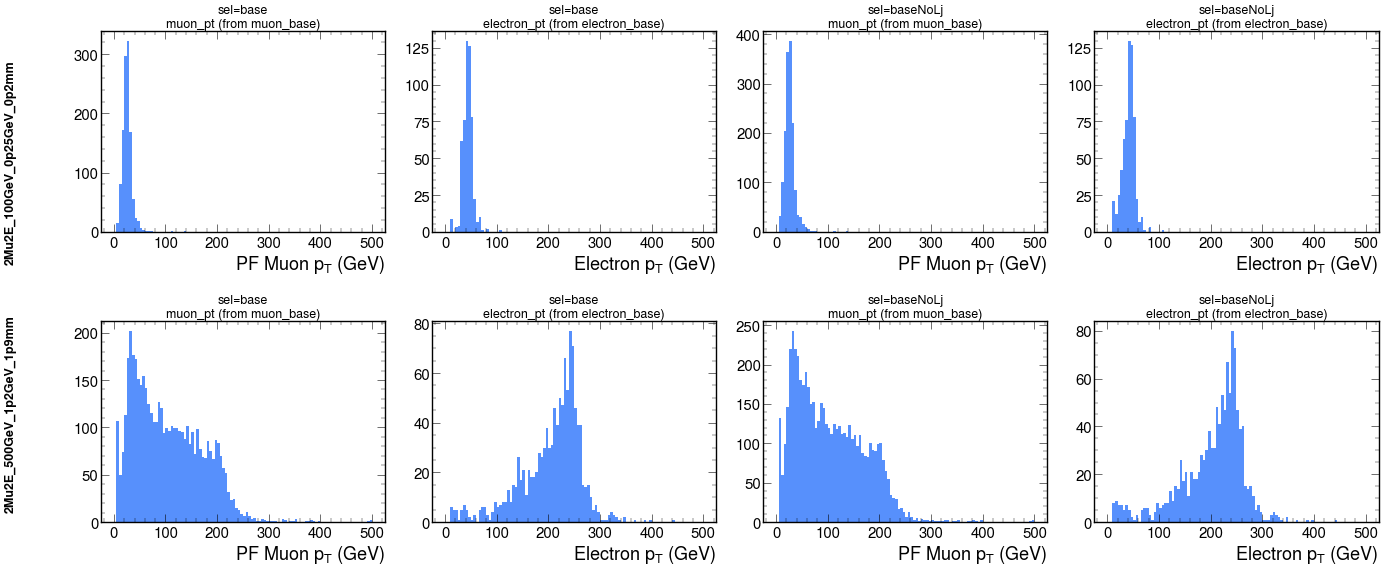

In [4]:
selections = ["base", "baseNoLj"]
hist_per_collection = {"muon_base": "muon_pt", "electron_base": "electron_pt"}
combos = [(sel, hc, hist_per_collection[hc]) for sel in selections for hc in hist_per_collection]
samples = list(samples_out.keys())

fig, axes = plt.subplots(len(samples), len(combos),
                         figsize=(7 * len(combos), 6 * len(samples)), squeeze=False)
for i, s in enumerate(samples):
    h = samples_out[s]["hists"]
    for j, (sel, hc, hname) in enumerate(combos):
        plt.sca(axes[i, j])
        utilities.plot(h[hname][sel, :], histtype="fill", skip_label=True)
        axes[i, j].set_title(f"sel={sel}\n{hname} (from {hc})", fontsize=18)
    bbox = axes[i, 0].get_position()
    fig.text(0.005, (bbox.y0 + bbox.y1) / 2, s, fontsize=18, rotation="vertical",
             va="center", ha="left", weight="bold")
plt.tight_layout(rect=(0.04, 0, 1, 1))
plt.show()

## Sharing outputs across collaborators

These outputs are world-readable under the group `lpcmetx` area, so anyone with grid access can read them — set `PRODUCER` to the other user and `STUDY` to their study dir under `coffea_outputs/<PRODUCER>/`, and the load cell above `xrdcp`s their files down for you. The `.meta.yaml` sidecar records the selections, hist collections, input file list, and SIDM commit behind each `.coffea`, so a reader can see exactly how it was made.

```bash
# see what a collaborator has shared (xrootd, not the /eos/uscms mount)
xrdfs root://cmseos.fnal.gov ls /store/group/lpcmetx/SIDM/coffea_outputs/OTHER_USER/
```